# Decision Trees and Random Forest Project  
## Bank Marketing Dataset

### lab Goal
In this lab, we will use the **Bank Marketing Dataset** to predict whether a customer will subscribe to a term deposit or not.

The target column is:

`y`

Where:

- `yes` means the customer subscribed.
- `no` means the customer did not subscribe.

We will build and compare two classification models:

1. **Decision Tree Classifier**
2. **Random Forest Classifier**

# Import Libraries

Import the usual libraries for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Get the Data

Use pandas to read the dataset as a dataframe called `bank`.

Important note:  
This dataset is separated by semicolons `;`, so we must use:

`sep=';'`

In [2]:
bank = pd.read_csv('bank.csv', sep=';')

Check the first rows of the dataset.

In [3]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Check the dataset information.

In [4]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


Check the statistical summary of the numerical columns.

In [5]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


Check the shape of the dataset.

In [6]:
bank.shape

(4521, 17)

Check if there are missing values.

In [7]:
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Check the target column distribution.

In [8]:
bank['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

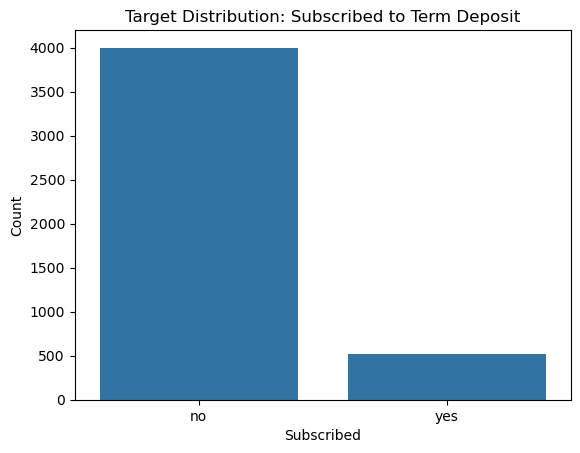

In [9]:
sns.countplot(x='y', data=bank)
plt.title('Target Distribution: Subscribed to Term Deposit')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

# Exploratory Data Analysis

Let's do some data visualization to understand the dataset.

We will create similar plots to the original project, but using suitable columns from the Bank Marketing Dataset.

## 1. Histogram of Age by Housing Loan

Create a histogram showing the age distribution for customers who have a housing loan and customers who do not.

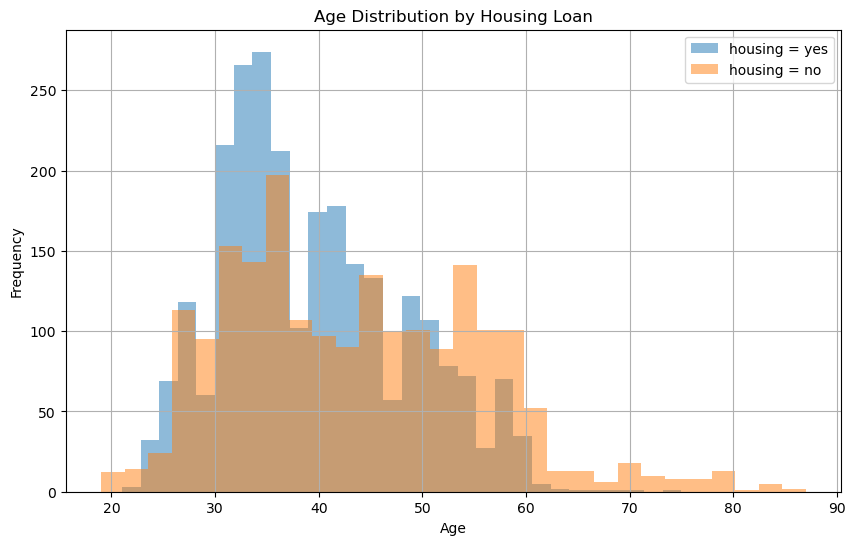

In [10]:
plt.figure(figsize=(10,6))
bank[bank['housing']=='yes']['age'].hist(alpha=0.5, bins=30, label='housing = yes')
bank[bank['housing']=='no']['age'].hist(alpha=0.5, bins=30, label='housing = no')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Housing Loan')
plt.show()

## 2. Histogram of Age by Subscription Status

Create a similar histogram, but this time based on the target column `y`.

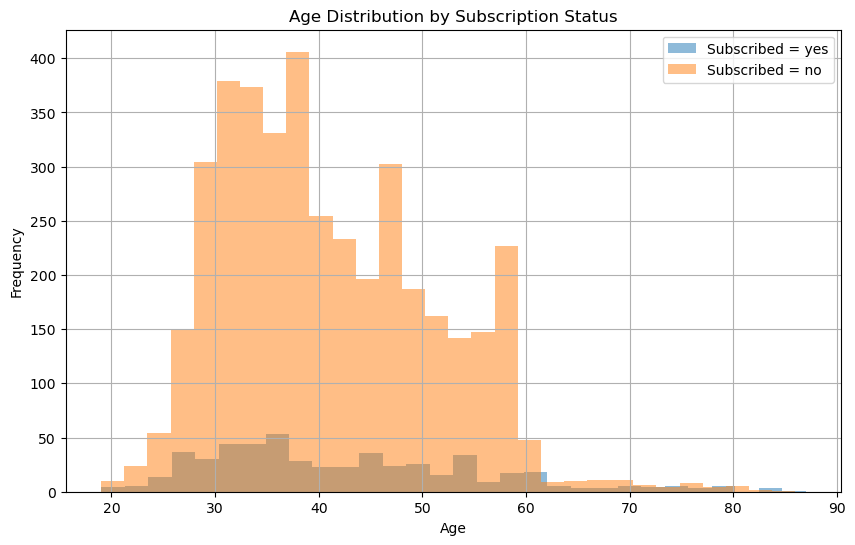

In [11]:
plt.figure(figsize=(10,6))
bank[bank['y']=='yes']['age'].hist(alpha=0.5, bins=30, label='Subscribed = yes')
bank[bank['y']=='no']['age'].hist(alpha=0.5, bins=30, label='Subscribed = no')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Subscription Status')
plt.show()

## 3. Countplot of Job by Subscription Status

Create a countplot showing the counts of customers by job type, with the color hue defined by the target column `y`.

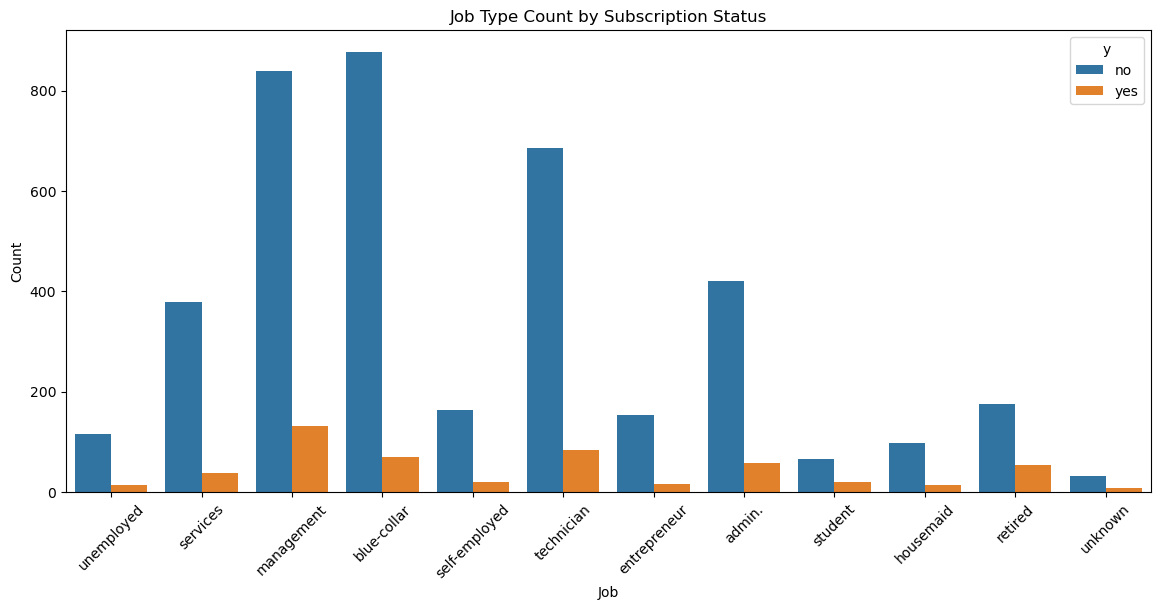

In [12]:
plt.figure(figsize=(14,6))
sns.countplot(x='job', data=bank, hue='y')
plt.xticks(rotation=45)
plt.title('Job Type Count by Subscription Status')
plt.xlabel('Job')
plt.ylabel('Count')
plt.show()

## 4. Jointplot Between Duration and Balance

Let's see the relationship between call duration and customer balance.

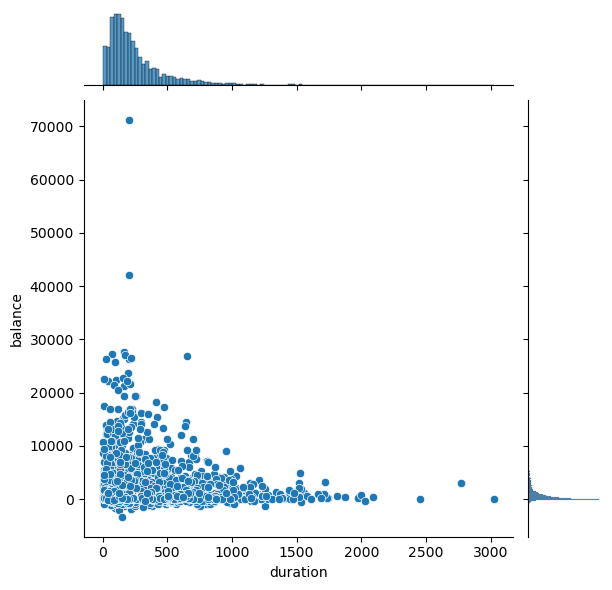

In [13]:
sns.jointplot(x='duration', y='balance', data=bank)
plt.show()

## 5. lmplot to Compare Trends

Create an lmplot to see whether the relationship between age and balance differs based on subscription status and housing loan status.

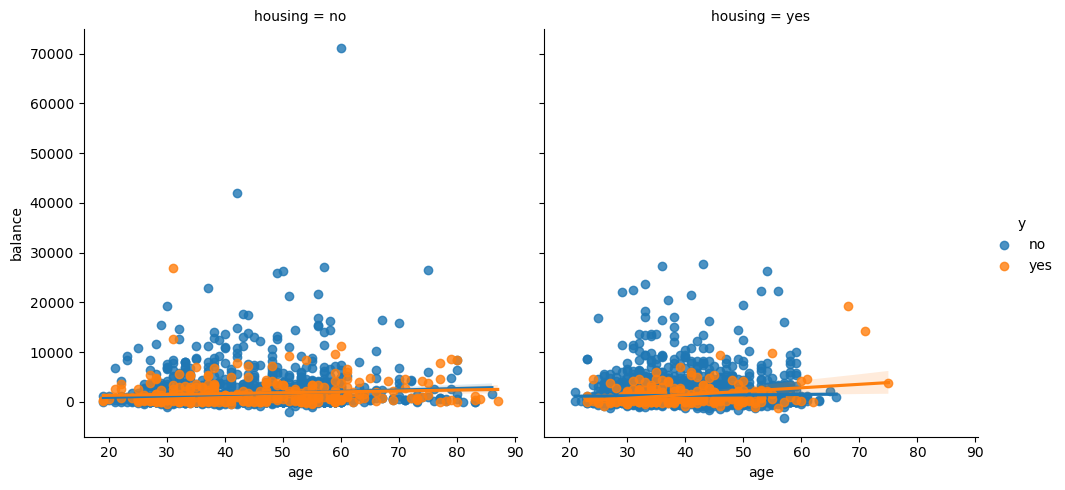

In [14]:
sns.lmplot(x='age', y='balance', data=bank, hue='y', col='housing', height=5, aspect=1)
plt.show()

## 6. Correlation Heatmap for Numerical Features

This plot helps us see the relationships between numerical variables.

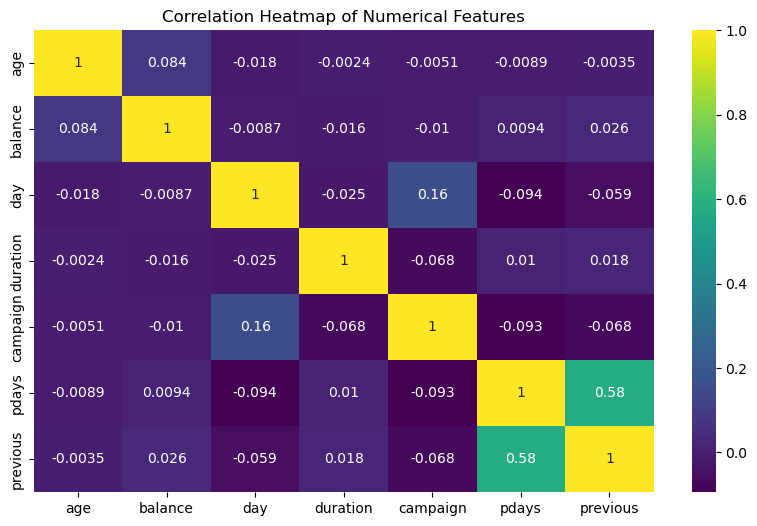

In [15]:
plt.figure(figsize=(10,6))
numeric_bank = bank.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_bank.corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Setting up the Data

Now we will prepare the data for our classification models.

Machine learning models from scikit-learn cannot directly understand text categories such as `job`, `marital`, or `education`.

Therefore, we need to convert categorical columns into dummy variables using:

`pd.get_dummies()`

Check the dataset information again.

In [16]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


## Categorical Features

These are the categorical columns that need to be converted into dummy variables.

In [17]:
cat_feats = ['job', 'marital', 'education', 'default', 'housing',
             'loan', 'contact', 'month', 'poutcome']

Before applying dummy variables, convert the target column `y` into numbers:

- `yes` becomes `1`
- `no` becomes `0`

In [18]:
bank_model = bank.copy()
bank_model['y'] = bank_model['y'].map({'no': 0, 'yes': 1})

Now use `pd.get_dummies()` to create a final dataframe with dummy variables.

In [19]:
final_data = pd.get_dummies(bank_model, columns=cat_feats, drop_first=True)

In [20]:
final_data.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,79,1,-1,0,0,False,False,...,False,False,False,False,False,True,False,False,False,True
1,33,4789,11,220,1,339,4,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,35,1350,16,185,1,330,1,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,199,4,-1,0,0,False,False,...,False,True,False,False,False,False,False,False,False,True
4,59,0,5,226,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True


In [21]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  4521 non-null   int64
 1   balance              4521 non-null   int64
 2   day                  4521 non-null   int64
 3   duration             4521 non-null   int64
 4   campaign             4521 non-null   int64
 5   pdays                4521 non-null   int64
 6   previous             4521 non-null   int64
 7   y                    4521 non-null   int64
 8   job_blue-collar      4521 non-null   bool 
 9   job_entrepreneur     4521 non-null   bool 
 10  job_housemaid        4521 non-null   bool 
 11  job_management       4521 non-null   bool 
 12  job_retired          4521 non-null   bool 
 13  job_self-employed    4521 non-null   bool 
 14  job_services         4521 non-null   bool 
 15  job_student          4521 non-null   bool 
 16  job_technician       452

# Train Test Split

Now it is time to split the data into a training set and a testing set.

We will use:

- 70% for training
- 30% for testing

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = final_data.drop('y', axis=1)
y = final_data['y']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

# Training a Decision Tree Model

First, we will train a single Decision Tree model.

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
dtree = DecisionTreeClassifier(random_state=101)

In [27]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

# Predictions and Evaluation for Decision Tree

Now evaluate the Decision Tree model using:

- Confusion Matrix
- Classification Report

In [28]:
predictions = dtree.predict(X_test)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
print(confusion_matrix(y_test, predictions))

[[1104   98]
 [  83   72]]


In [31]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1202
           1       0.42      0.46      0.44       155

    accuracy                           0.87      1357
   macro avg       0.68      0.69      0.68      1357
weighted avg       0.87      0.87      0.87      1357



# Training the Random Forest Model

Now we will train a Random Forest model and compare it with the Decision Tree model.

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rfc = RandomForestClassifier(n_estimators=100, random_state=101)

In [34]:
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=101)

# Predictions and Evaluation for Random Forest

In [35]:
rfc_pred = rfc.predict(X_test)

In [36]:
print(confusion_matrix(y_test, rfc_pred))

[[1178   24]
 [ 112   43]]


In [37]:
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      1202
           1       0.64      0.28      0.39       155

    accuracy                           0.90      1357
   macro avg       0.78      0.63      0.67      1357
weighted avg       0.88      0.90      0.88      1357



# Final Model Comparison

Now we compare the two models using common classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, rfc_pred)
    ],
    'Precision': [
        precision_score(y_test, predictions),
        precision_score(y_test, rfc_pred)
    ],
    'Recall': [
        recall_score(y_test, predictions),
        recall_score(y_test, rfc_pred)
    ],
    'F1-Score': [
        f1_score(y_test, predictions),
        f1_score(y_test, rfc_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.866618,0.423529,0.464516,0.443077
1,Random Forest,0.899779,0.641791,0.277419,0.387387


# Conclusion

In this lab
, we used the Bank Marketing Dataset to predict whether a customer will subscribe to a term deposit or not.

We trained two models:

1. Decision Tree Classifier
2. Random Forest Classifier

After comparing the models using the classification report and the comparison table, we can decide which model performed better.

Usually, Random Forest performs better than a single Decision Tree because it combines multiple trees and reduces overfitting.

# Notes for Submission

Make sure the following files are in the same folder:

1. This notebook file
2. `bank.csv`

Then run the notebook cells from top to bottom.